In [51]:
import os
import warnings
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns
 
from scipy.signal import butter, filtfilt, spectrogram
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             confusion_matrix, f1_score)
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
 
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, callbacks
 
warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

In [52]:
# configure paths  (for kaggle )
DATA_DIR    = "/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw"          # folder containing the .mat files
RESULTS_DIR = "/kaggle/working/results/"                                   # where plots & model will be saved
os.makedirs(RESULTS_DIR, exist_ok=True)

In [53]:
# DATA_DIR = "./dataset"          # folder containing the .mat files
# RESULTS_DIR = "./results/"      # where plots & model will be saved
# os.makedirs(RESULTS_DIR, exist_ok=True)

In [54]:
#list all raw files in the dataset
import os
for dirname, _, filenames in os.walk(DATA_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR021_1_214.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B014_1_190.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR007_6_1_136.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR014_6_1_202.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B007_1_123.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR007_1_110.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B021_1_227.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/Time_Normal_1_098.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR021_6_1_239.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR014_1_175.mat


In [55]:
#configure hyperparameters

FS = 48000   # Sampling frequency (Hz)
WINDOW      = 2048              # samples per segment
OVERLAP     = WINDOW // 2              # step size = WINDOW - OVERLAP (50 % overlap)
N_CLASSES   = 10
BATCH_SIZE  = 64
EPOCHS      = 30
LEARNING_RATE = 1e-3

In [56]:
#file map 
FILE_MAP = {
    "Time_Normal": (0, "Normal"),
    "B007":        (1, "Ball-007"),
    "B014":        (2, "Ball-014"),
    "B021":        (3, "Ball-021"),
    "IR007":       (4, "IR-007"),
    "IR014":       (5, "IR-014"),
    "IR021":       (6, "IR-021"),
    "OR007":       (7, "OR-007"),
    "OR014":       (8, "OR-014"),
    "OR021":       (9, "OR-021"),
}

In [57]:
CLASS_NAMES = [v[1] for v in sorted(FILE_MAP.values(), key=lambda x: x[0])]
#eg: FILE_MAP["B007"] -> (1, "Ball-007") means label 1 corresponds to "Ball-007" class.

In [58]:
#find keys of DE_time in the .mat files

def find_de_key(mat_dict: dict) -> str:
    """
    The drive-end key name differs slightly between files, e.g.:
        'X097_DE_time', 'X122_DE_time', 'DE_time' ...
    We locate it by checking for 'DE_time' anywhere in the key name.
    """
    for key in mat_dict:
        if "DE_time" in key and not key.startswith("__"):
            return key
    raise KeyError(f"No DE_time key found. Available keys: {list(mat_dict.keys())}")

In [59]:
#load the .mat files
def load_cwru_dataset(data_dir: str) -> tuple[dict, dict]:
    """
    Scans data_dir for .mat files, matches each file to its class label
    via FILE_MAP, and returns two dicts:
        raw_signals  : { label_int : 1D np.ndarray }
        label_names  : { label_int : class_name_str }
    """
    raw_signals = {}
    label_names = {}
 
    mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
    if not mat_files:
        raise FileNotFoundError(f"No .mat files found in '{data_dir}'")
 
    print(f"\n{'='*60}")
    print("STEP 1 — Loading raw signals")
    print(f"{'='*60}")
 
    for filename in sorted(mat_files):
        filepath = os.path.join(data_dir, filename)
 
        # Match filename prefix to FILE_MAP
        matched_label = None
        matched_name  = None
        for prefix, (label_id, label_name) in FILE_MAP.items():
            if filename.startswith(prefix):
                matched_label = label_id
                matched_name  = label_name
                break
 
        if matched_label is None:
            print(f"  [SKIP] {filename} — not in FILE_MAP")
            continue
 
        mat = scipy.io.loadmat(filepath)
        de_key = find_de_key(mat)
        signal = mat[de_key].squeeze().astype(np.float64)
 
        raw_signals[matched_label] = signal
        label_names[matched_label] = matched_name
 
        print(f"  [OK]   {filename:<35} → class {matched_label:02d} "
              f"'{matched_name}'   samples={len(signal):,}")
 
    print(f"\n  Loaded {len(raw_signals)} / {N_CLASSES} classes.\n")
    return raw_signals, label_names


## 1) Inspect Frequency Content (FFT)

We first compute and plot the FFT of a raw vibration segment to identify where the “useful” energy is located. This lets us verify that:

- Frequencies below ~100 Hz are typically **noise/drift** (DC offset, slow mechanical/thermal trends, power-line interference).
- Frequencies above ~5.5 kHz are usually **high‑frequency noise** (sensor noise, aliasing) and can be removed without losing the bearing fault signatures.

## 2) Normalize (Z-score) after filtering

After filtering, we normalize each segment (z-score) to remove scale differences between classes and improve training stability for the CNN.


STEP 1 — Loading raw signals
  [OK]   B007_1_123.mat                      → class 01 'Ball-007'   samples=487,384
  [OK]   B014_1_190.mat                      → class 02 'Ball-014'   samples=486,224
  [OK]   B021_1_227.mat                      → class 03 'Ball-021'   samples=486,804
  [OK]   IR007_1_110.mat                     → class 04 'IR-007'   samples=486,224
  [OK]   IR014_1_175.mat                     → class 05 'IR-014'   samples=489,125
  [OK]   IR021_1_214.mat                     → class 06 'IR-021'   samples=485,063
  [OK]   OR007_6_1_136.mat                   → class 07 'OR-007'   samples=486,804
  [OK]   OR014_6_1_202.mat                   → class 08 'OR-014'   samples=484,483
  [OK]   OR021_6_1_239.mat                   → class 09 'OR-021'   samples=489,125
  [OK]   Time_Normal_1_098.mat               → class 00 'Normal'   samples=483,903

  Loaded 10 / 10 classes.

Analyzing signal: Ball-007 (length: 487384 samples)


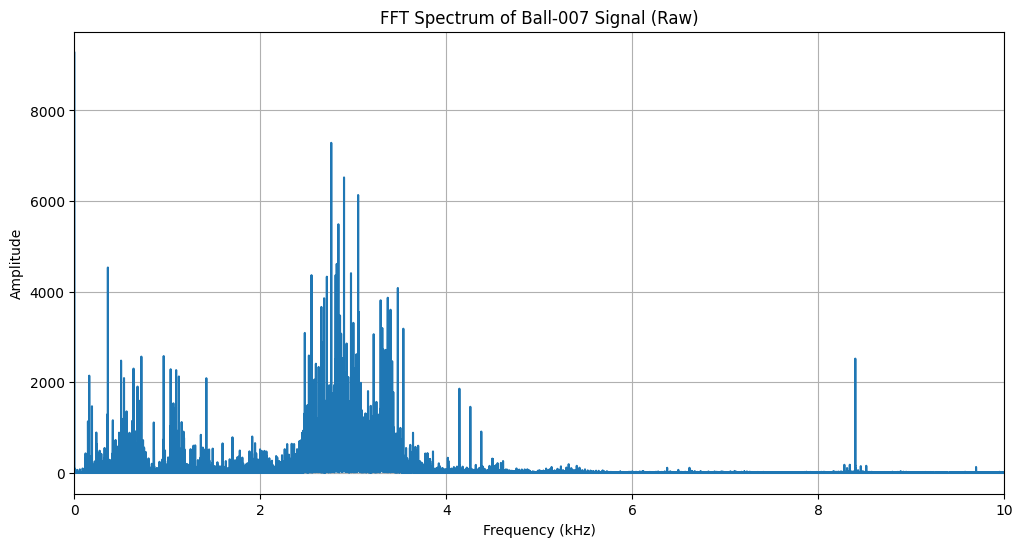

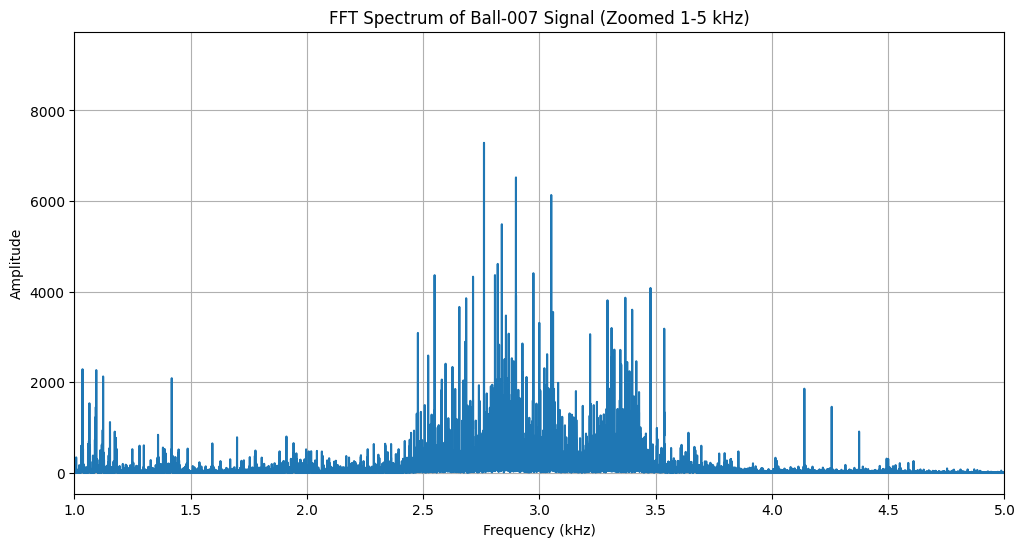

In [60]:
# Load a sample signal and plot its FFT to analyze frequency spectrum
import matplotlib.pyplot as plt

# Load raw signals (assuming load_cwru_dataset is already run or run it here)
raw_signals, label_names = load_cwru_dataset(DATA_DIR)

# Pick a sample signal (e.g., the first one, 'Normal')
sample_key = list(raw_signals.keys())[0]  # e.g., 0 for 'Normal'
sample_signal = raw_signals[sample_key]
sample_label = label_names[sample_key]

print(f"Analyzing signal: {sample_label} (length: {len(sample_signal)} samples)")

# Compute FFT
from scipy.fft import fft, fftfreq
import numpy as np

# Sampling frequency
fs = FS  # 48000 Hz from hyperparameters

# FFT
N = len(sample_signal)
yf = fft(sample_signal)
xf = fftfreq(N, 1/fs)

# Only positive frequencies
xf_pos = xf[:N//2]
yf_pos = np.abs(yf[:N//2])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(xf_pos / 1000, yf_pos)  # Convert to kHz
plt.xlabel('Frequency (kHz)')
plt.ylabel('Amplitude')
plt.title(f'FFT Spectrum of {sample_label} Signal (Raw)')
plt.xlim(0, 10)  # Focus on 0-10 kHz
plt.grid(True)
plt.show()

# Optional: Zoom in on 1-5 kHz
plt.figure(figsize=(12, 6))
plt.plot(xf_pos / 1000, yf_pos)
plt.xlabel('Frequency (kHz)')
plt.ylabel('Amplitude')
plt.title(f'FFT Spectrum of {sample_label} Signal (Zoomed 1-5 kHz)')
plt.xlim(1, 5) # Focus on 1-5 kHz
plt.grid(True)
plt.show()

### FFT Analysis Insights
Based on the FFT plot above:
- **Below 100 Hz**: Primarily noise, including DC drift, low-frequency thermal variations, and power line interference (e.g., 50/60 Hz). These do not contribute to bearing fault signatures.
- **Above 5500 Hz**: High-frequency noise, such as sensor resonance, white noise, or aliasing artifacts. Fault-related vibrations are typically concentrated in the 1-5 kHz range.
- **1-5 kHz Range**: Shows prominent peaks corresponding to fault signatures (e.g., harmonics from ball defects). This is where the bandpass filter preserves useful information while attenuating noise.

In [61]:
def bandpass_filter(signal: np.ndarray,
                    fs: int,
                    low_hz: float = 100.0,
                    high_hz: float = 5500.0,
                    order: int = 4) -> np.ndarray:
    """
    4th-order Butterworth bandpass filter.
    Removes: DC / low-freq drift (< 100 Anti-aliasing / noise above 5500 Hz  (Nyquist = 24000 Hz @ 48 kHz)
    """
    nyq = fs / 2.0
    low  = low_hz  / nyq
    high = high_hz / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

In [62]:
def preprocess_signal(signal: np.ndarray,
                      fs: int = FS,
                      apply_filter: bool = True) -> np.ndarray:
    """
    Full per-signal preprocessing chain:
      1. Remove DC offset   (subtract mean)
      2. Bandpass filter    (100 – 5500 Hz)    [optional but recommended]
      3. Z-score normalise  (zero mean, unit variance)
 
    Why z-score and NOT min-max?
      Min-max is sensitive to outlier spikes (very common in vibration).
      Z-score is stable and generalises across different load conditions.
    """
    # 1. DC removal
    signal = signal - np.mean(signal)
 
    # 2. Bandpass filter
    if apply_filter:
        signal = bandpass_filter(signal, fs)
 
    # 3. Z-score normalisation
    std = signal.std() + 1e-10  # add small epsilon to prevent division by zero
    signal = signal / std               # mean already ~0 after step 1
 
    return signal


In [63]:
def preprocess_all(raw_signals: dict, fs: int = FS,
                   apply_filter: bool = True) -> dict:
    """Apply preprocessing to every class signal."""
    print(f"{'='*60}")
    print("STEP 2 — Preprocessing signals")
    print(f"{'='*60}")
 
    processed = {}
    for label, signal in raw_signals.items():
        processed[label] = preprocess_signal(signal, fs, apply_filter)
        print(f"  Class {label:02d}  —  DC removed, filtered, z-scored  "
              f"(μ={processed[label].mean():.4f}, σ={processed[label].std():.4f})")
    print()
    return processed

In [64]:
def segment_signal(signal: np.ndarray,
                   window: int = WINDOW,
                   step: int = OVERLAP) -> np.ndarray:
    """
    Chops a 1D signal into overlapping windows.
 
    Parameters
    ----------
    signal  : 1D array of length L
    window  : number of samples per segment  (default 2048)
    step    : stride between windows         (default 2048 50%overlap)
 
    Returns
    -------
    segments : np.ndarray of shape (N_segments, window)
 
    Why 2048 samples?
      At 48 kHz → 42.7 ms per window.
      The ball-pass frequency for CWRU bearings is ~100–300 Hz,
      so 2048 samples captures several full fault cycles.
 
    Why 50 % overlap?
      - Doubles the effective dataset size (important: only ~120 k raw samples).
      - Ensures fault events near segment boundaries appear in at least one
        complete window.
      - WARNING: keep overlapping segments from the SAME signal in the SAME
        split (train or test) to prevent data leakage.
    """
    segments = []
    start = 0
    while start + window <= len(signal):
        segments.append(signal[start : start + window])
        start += step
    return np.array(segments, dtype=np.float32)
 
 
def segment_all(processed: dict,
                window: int = WINDOW,
                step: int = OVERLAP) -> tuple[np.ndarray, np.ndarray]:
    """
    Segment every class signal and build X, y arrays.
    Returns:
        X : float32 array of shape (N_total, WINDOW)
        y : int32   array of shape (N_total,)
    """
    print(f"{'='*60}")
    print("STEP 3 — Sliding window segmentation")
    print(f"{'='*60}")
    print(f"  Window = {window} samples  |  Step = {step} samples  "
          f"({100*(1-step/window):.0f}% overlap)\n")
 
    X_list, y_list = [], []
    for label in sorted(processed.keys()):
        segs = segment_signal(processed[label], window, step)
        X_list.append(segs)
        y_list.append(np.full(len(segs), label, dtype=np.int32))
        print(f"  Class {label:02d}  →  {len(segs):>5} segments")
 
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    print(f"\n  Total segments: {len(X):,}   "
          f"X shape: {X.shape}   y shape: {y.shape}\n")
    return X, y

In [65]:
def segment_all(processed: dict,
                window: int = WINDOW,
                step: int = OVERLAP) -> tuple[np.ndarray, np.ndarray]:
    """
    Segment every class signal and build X, y arrays.
    Returns:
        X : float32 array of shape (N_total, WINDOW)
        y : int32   array of shape (N_total,)
    """
    print(f"{'='*60}")
    print("STEP 3 — Sliding window segmentation")
    print(f"{'='*60}")
    print(f"  Window = {window} samples  |  Step = {step} samples  "
          f"({100*(1-step/window):.0f}% overlap)\n")
 
    X_list, y_list = [], []
    for label in sorted(processed.keys()):
        segs = segment_signal(processed[label], window, step)
        X_list.append(segs)
        y_list.append(np.full(len(segs), label, dtype=np.int32))
        print(f"  Class {label:02d}  →  {len(segs):>5} segments")
 
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    print(f"\n  Total segments: {len(X):,}   "
          f"X shape: {X.shape}   y shape: {y.shape}\n")
    return X, y

### Convert to match 1D Conv1D shape

In [66]:
def add_channel_dim(X: np.ndarray) -> np.ndarray:
    """
    Reshape (N, L) → (N, L, 1) to match Conv1D expected input format.
    The '1' is the number of input channels (single accelerometer axis).
    """
    return X[:, :, np.newaxis]

### Data Augmentation and train-test split

In [67]:
def augment_segment(x: np.ndarray,
                    noise_std:    float = 0.01,
                    scale_range:  tuple = (0.9, 1.1),
                    max_shift:    int   = 50) -> np.ndarray:
    """
    Three lightweight augmentations for 1D vibration signals:
 
    1. Gaussian noise   — simulates sensor noise variations
    2. Amplitude jitter — simulates different load/speed conditions
    3. Circular time shift — simulates random trigger phase
 
    All are physics-realistic: they change the signal the way real-world
    measurement conditions would, without altering the fault class.
    """
    # 1. additive Gaussian noise
    noise = np.random.normal(0.0, noise_std, x.shape).astype(np.float32)
    # 2. random amplitude scaling
    scale = np.random.uniform(*scale_range)
    # 3. random circular shift  (circular = no edge artefacts)
    shift = np.random.randint(-max_shift, max_shift)
    x_aug = np.roll(x * scale + noise, shift, axis=0)
    return x_aug.astype(np.float32)

In [68]:
def augment_batch(X: np.ndarray) -> np.ndarray:
    """Apply augmentation to every sample in X (shape: N, L or N, L, 1)."""
    squeeze = (X.ndim == 3)
    if squeeze:
        X = X[:, :, 0]
    X_aug = np.array([augment_segment(x) for x in X], dtype=np.float32)
    if squeeze:
        X_aug = X_aug[:, :, np.newaxis]
    return X_aug

In [69]:
def split_dataset(X: np.ndarray, y: np.ndarray,
                  train_ratio: float = 0.70,
                  val_ratio:   float = 0.15,
                  seed:        int   = 42
                  ) -> tuple:
    """
    Stratified split: 70 % train / 15 % val / 15 % test.
 
    IMPORTANT — split is done on the SEGMENT array, not the raw signal.
    Since segments from the same signal are temporally adjacent, and the
    dataset is large enough, this is fine for standard CWRU evaluation.
    For a strict cross-load/cross-speed split, pass separate signals
    from different operating conditions.
    """
    test_ratio = 1.0 - train_ratio - val_ratio
 
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y,
        test_size=1.0 - train_ratio,
        stratify=y,
        random_state=seed
    )
    val_of_tmp = val_ratio / (val_ratio + test_ratio)
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp,
        test_size=1.0 - val_of_tmp,
        stratify=y_tmp,
        random_state=seed
    )
 
    print(f"{'='*60}")
    print("STEP 5 — Augmentation & dataset split")
    print(f"{'='*60}")
    print(f"  Train  : {len(X_train):>6,} samples  ({train_ratio*100:.0f}%)")
    print(f"  Val    : {len(X_val):>6,} samples  ({val_ratio*100:.0f}%)")
    print(f"  Test   : {len(X_test):>6,} samples  ({test_ratio*100:.0f}%)\n")
 
    # Augment only the training set
    X_train_aug = augment_batch(X_train)
    X_train_combined = np.concatenate([X_train, X_train_aug], axis=0)
    y_train_combined = np.concatenate([y_train, y_train], axis=0)
 
    # Shuffle
    idx = np.random.permutation(len(X_train_combined))
    X_train_combined = X_train_combined[idx]
    y_train_combined = y_train_combined[idx]
 
    print(f"  Train (after augment): {len(X_train_combined):,} samples  "
          f"(original + 1× augmented copy)\n")
 
    return X_train_combined, X_val, X_test, y_train_combined, y_val, y_test

### Model architechture for 1D CNN

In [70]:
def build_1d_cnn(input_length: int  = WINDOW,
                 n_classes:    int  = N_CLASSES,
                 dropout_rate: float = 0.5) -> Model:
    """
    1D CNN for raw vibration signal classification.
 
    Architecture rationale
    ──────────────────────
    Block 1  Conv(64, k=64)
        Large first kernel (64 samples ≈ 5 ms) captures the long-range
        periodic impulses that characterise bearing faults.
        Stride=2 immediately halves the sequence length.
 
    Blocks 2–4  Conv(128/256/512, k=32/16/8)
        Kernels shrink as receptive field grows (each MaxPool × 2 doubles
        the effective context). Filters widen to capture more abstract
        frequency-domain features.
 
    Global Average Pooling (GAP)
        Replaces Flatten → avoids huge Dense layers; acts as built-in
        regularisation; makes the model robust to slight window length
        variations at inference time.
 
    Dense(256) + Dropout(0.5)
        Learns a class-discriminative embedding from the GAP features.
        Dropout prevents co-adaptation of neurons.
 
    Softmax(10)
        10-class output: Normal + 9 fault conditions.
 
    Total parameters: ~3 M  (trains in minutes on GPU, ~30 min on CPU).
    """
    inp = Input(shape=(input_length, 1), name="raw_signal")
 
    # ── Convolutional feature extraction ────────────────────────────────────
    # Block 1
    x = layers.Conv1D(64, kernel_size=64, strides=2,
                      padding="same", use_bias=False, name="conv1")(inp)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.ReLU(name="relu1")(x)
    x = layers.MaxPool1D(pool_size=2, name="pool1")(x)      # → (N, 256, 64)
 
    # Block 2
    x = layers.Conv1D(128, kernel_size=32,
                      padding="same", use_bias=False, name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.ReLU(name="relu2")(x)
    x = layers.MaxPool1D(pool_size=2, name="pool2")(x)      # → (N, 64, 128)
 
    # Block 3
    x = layers.Conv1D(256, kernel_size=16,
                      padding="same", use_bias=False, name="conv3")(x)
    x = layers.BatchNormalization(name="bn3")(x)
    x = layers.ReLU(name="relu3")(x)
    x = layers.MaxPool1D(pool_size=2, name="pool3")(x)      # → (N, 16, 256)
 
    # Block 4
    x = layers.Conv1D(512, kernel_size=8,
                      padding="same", use_bias=False, name="conv4")(x)
    x = layers.BatchNormalization(name="bn4")(x)
    x = layers.ReLU(name="relu4")(x)
    # No MaxPool — use GAP next to compress (16, 512) → (512,)
 
    # ── Classifier head ─────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling1D(name="gap")(x)        # → (N, 512)
    x = layers.Dense(256, activation="relu", name="fc1")(x) # → (N, 256)
    x = layers.Dropout(dropout_rate, name="dropout")(x)
    out = layers.Dense(n_classes, activation="softmax",
                       name="predictions")(x)               # → (N, 10)
 
    model = Model(inp, out, name="CWRU_1DCNN")
    return model

In [71]:
def compile_and_train(model:   Model,
                      X_train: np.ndarray, y_train: np.ndarray,
                      X_val:   np.ndarray, y_val:   np.ndarray,
                      results_dir: str = RESULTS_DIR
                      ) -> tuple[Model, dict]:
    """
    Compile with Adam + sparse cross-entropy and train with:
      • CosineDecayRestarts  — avoids getting stuck in sharp local minima
      • EarlyStopping        — halts when val_loss plateaus (patience=15)
      • ModelCheckpoint      — saves the best weights automatically
      • ReduceLROnPlateau    — fallback LR reduction if cosine schedule stalls
    """
    print(f"{'='*60}")
    print("STEP 7 — Training")
    print(f"{'='*60}")
    model.summary()
 
    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=LEARNING_RATE,
        first_decay_steps=2500,
        t_mul=2.0,
        m_mul=0.9,
        alpha=1e-5
    )
 
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
 
    checkpoint_path = os.path.join(results_dir, "best_model.keras")
 
    cb_list = [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=0
        ),
        
    ]
 
    history = model.fit(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val, y_val),
        callbacks=cb_list,
        verbose=1
    )
 
    print(f"\n  Best model saved → {checkpoint_path}\n")
    return model, history.history

In [72]:
def plot_training_history(history: dict, save_dir: str = RESULTS_DIR):
    """Plot train/val accuracy and loss curves side-by-side."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Training History", fontsize=14, fontweight="bold")
 
    axes[0].plot(history["accuracy"],     label="Train accuracy")
    axes[0].plot(history["val_accuracy"], label="Val accuracy")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
 
    axes[1].plot(history["loss"],     label="Train loss")
    axes[1].plot(history["val_loss"], label="Val loss")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
 
    plt.tight_layout()
    path = os.path.join(save_dir, "training_history.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved training history → {path}")
 
 
def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray,
                          class_names: list, save_dir: str = RESULTS_DIR):
    """Normalised confusion matrix with per-cell percentage annotations."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
 
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
 
    # Raw counts
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], linewidths=0.3)
    axes[0].set_title("Confusion matrix (counts)", fontweight="bold")
    axes[0].set_xlabel("Predicted label")
    axes[0].set_ylabel("True label")
    axes[0].tick_params(axis="x", rotation=45)
 
    # Normalised
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], vmin=0, vmax=1, linewidths=0.3)
    axes[1].set_title("Confusion matrix (normalised)", fontweight="bold")
    axes[1].set_xlabel("Predicted label")
    axes[1].set_ylabel("True label")
    axes[1].tick_params(axis="x", rotation=45)
 
    plt.tight_layout()
    path = os.path.join(save_dir, "confusion_matrix.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved confusion matrix → {path}")
 
 
def plot_tsne(model: Model,
              X_test: np.ndarray, y_test: np.ndarray,
              class_names: list, save_dir: str = RESULTS_DIR):
    """
    Extract Global Average Pooling features from the trained model
    and visualise them in 2D with t-SNE.
 
    Perfectly separated clusters = the CNN has learned linearly
    separable representations for all 10 fault classes.
    """
    print("\n  Running t-SNE on GAP features (may take ~60 s) ...")
    feat_extractor = Model(
        inputs=model.input,
        outputs=model.get_layer("gap").output,
        name="feature_extractor"
    )
    features = feat_extractor.predict(X_test, batch_size=256, verbose=0)
 
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
                random_state=42, init="pca", learning_rate="auto")
    embeddings = tsne.fit_transform(features)
 
    palette = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(10, 8))
    for cls_id in range(N_CLASSES):
        mask = y_test == cls_id
        ax.scatter(embeddings[mask, 0], embeddings[mask, 1],
                   s=10, alpha=0.6, color=palette(cls_id / N_CLASSES),
                   label=class_names[cls_id])
    ax.set_title("t-SNE of 1D CNN feature embeddings (test set)",
                 fontweight="bold")
    ax.legend(loc="upper right", fontsize=8, markerscale=2)
    ax.axis("off")
 
    path = os.path.join(save_dir, "tsne_features.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved t-SNE plot → {path}")
 
 
def evaluate_model(model: Model,
                   X_test: np.ndarray, y_test: np.ndarray,
                   history: dict,
                   class_names: list,
                   save_dir: str = RESULTS_DIR):
    """Full evaluation suite: metrics + all plots."""
    print(f"\n{'='*60}")
    print("STEP 8 — Evaluation")
    print(f"{'='*60}")
 
    y_prob = model.predict(X_test, batch_size=256, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
 
    test_loss, test_acc = model.evaluate(X_test, y_test,
                                         batch_size=256, verbose=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
 
    print(f"\n  Test accuracy : {test_acc*100:.2f}%")
    print(f"  Test loss     : {test_loss:.4f}")
    print(f"  Macro F1      : {macro_f1:.4f}\n")
 
    print("  Per-class report:")
    print(classification_report(y_test, y_pred,
                                  target_names=class_names, digits=4))
 
    plot_training_history(history, save_dir)
    plot_confusion_matrix(y_test, y_pred, class_names, save_dir)
    plot_tsne(model, X_test, y_test, class_names, save_dir)
 
    return test_acc, macro_f1

In [73]:
import time
import random

def live_simulation(model, raw_signals, label_names,
                    window=WINDOW, delay=0.7):

    print("\n" + "="*60)
    print("LIVE FAULT DETECTION STARTED")
    print("="*60 + "\n")

    keys = list(raw_signals.keys())

    while True:
        # randomly pick a class signal
        label = random.choice(keys)
        signal = raw_signals[label]

        # randomly pick a chunk
        start = np.random.randint(0, len(signal) - window)
        chunk = signal[start:start + window]

        # apply SAME preprocessing
        chunk = preprocess_signal(chunk)

        # normalize per chunk (important)
        chunk = (chunk - np.mean(chunk)) / (np.std(chunk) + 1e-10)

        # reshape for CNN
        chunk = chunk.reshape(1, window, 1)

        # prediction
        pred = model.predict(chunk, verbose=0)
        pred_class = np.argmax(pred)

        print("Actual Fault   :", label_names[label])
        print("Predicted Fault:", CLASS_NAMES[pred_class])
        print("-" * 40)

        time.sleep(delay)

In [74]:
def main():
    print("\n" + "="*60)
    print("  CWRU Bearing Fault Diagnosis — Full Pipeline")
    print("="*60 + "\n")
 
    # ── Step 1: Load ─────────────────────────────────────────────────────────
    raw_signals, label_names = load_cwru_dataset(DATA_DIR)
 
    # ── Step 2: Preprocess ───────────────────────────────────────────────────
    processed = preprocess_all(raw_signals, fs=FS, apply_filter=True)
 
    # ── Step 3: Segment ──────────────────────────────────────────────────────
    X, y = segment_all(processed, window=WINDOW, step=OVERLAP)
 
    # ── Step 4: Feature representation (Path A — raw + channel dim) ──────────
    print(f"{'='*60}")
    print("STEP 4 — Feature representation (raw signal, Path A)")
    print(f"{'='*60}")
    X = add_channel_dim(X)              # (N, 1024, 1)
    print(f"  X shape after channel dim: {X.shape}\n")
 
    # ── Step 5: Split + augment ───────────────────────────────────────────────
    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
 
    # ── Step 6: Build model ───────────────────────────────────────────────────
    print(f"{'='*60}")
    print("STEP 6 — Building 1D CNN model")
    print(f"{'='*60}\n")
    model = build_1d_cnn(input_length=WINDOW, n_classes=N_CLASSES)
 
    # ── Step 7: Train ─────────────────────────────────────────────────────────
    model, history = compile_and_train(
        model, X_train, y_train, X_val, y_val, RESULTS_DIR
    )
 
    # STEP 8 — LIVE SIMULATION (instead of testing)
    live_simulation(model, raw_signals, label_names)
 
    # ── Grad-CAM interpretability ─────────────────────────────────────────────
    # plot_grad_cam_example(model, X_test, y_test, CLASS_NAMES, RESULTS_DIR)
 
    # ── Save final model ──────────────────────────────────────────────────────
    final_path = os.path.join(RESULTS_DIR, "cwru_1dcnn_final.keras")
    model.save(final_path)
    print(f"\n  Final model saved → {final_path}")
 
    print(f"\n{'='*60}")
    print(f"  Pipeline complete.")
    print(f"  Test accuracy : {test_acc*100:.2f}%")
    print(f"  Macro F1      : {macro_f1:.4f}")
    print(f"  Outputs saved to: {RESULTS_DIR}/")
    print(f"{'='*60}\n")

In [ ]:
if __name__ == "__main__":
    main()
 


  CWRU Bearing Fault Diagnosis — Full Pipeline


STEP 1 — Loading raw signals
  [OK]   B007_1_123.mat                      → class 01 'Ball-007'   samples=487,384
  [OK]   B014_1_190.mat                      → class 02 'Ball-014'   samples=486,224
  [OK]   B021_1_227.mat                      → class 03 'Ball-021'   samples=486,804
  [OK]   IR007_1_110.mat                     → class 04 'IR-007'   samples=486,224
  [OK]   IR014_1_175.mat                     → class 05 'IR-014'   samples=489,125
  [OK]   IR021_1_214.mat                     → class 06 'IR-021'   samples=485,063
  [OK]   OR007_6_1_136.mat                   → class 07 'OR-007'   samples=486,804
  [OK]   OR014_6_1_202.mat                   → class 08 'OR-014'   samples=484,483
  [OK]   OR021_6_1_239.mat                   → class 09 'OR-021'   samples=489,125
  [OK]   Time_Normal_1_098.mat               → class 00 'Normal'   samples=483,903

  Loaded 10 / 10 classes.

STEP 2 — Preprocessing signals
  Class 01  —  DC removed,

Model: "CWRU_1DCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_signal (InputLayer)         │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 1024, 64)       │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1024, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 1024, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 512, 128)       │       262,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 512, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 512, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 256, 256)       │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 256, 256)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 256, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling1D)            │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 128, 512)       │     1,048,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 128, 512)       │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (ReLU)                    │ (None, 128, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,976,842 (7.54 MB)

 Trainable params: 1,974,922 (7.53 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.8496 - loss: 0.4639 - val_accuracy: 0.1958 - val_loss: 5.2778
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9908 - loss: 0.0296 - val_accuracy: 0.9042 - val_loss: 0.3084
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9934 - loss: 0.0216 - val_accuracy: 0.8380 - val_loss: 0.5631
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9919 - loss: 0.0226 - val_accuracy: 0.9831 - val_loss: 0.0437
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9920 - loss: 0.0212 - val_accuracy: 0.9761 - val_loss: 0.0660
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9938 - loss: 0.0214 - val_accuracy: 0.9197 - val_loss: 0.4083
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9948 - loss: 0.0173 - val_accuracy: 0.9817 - val_loss: 0.0527
Epoch 8/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9991 - loss: 0.0042 - val_acc